<div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 24px; border-radius: 12px; color: white; margin-bottom: 24px; overflow: hidden;">
    <h1 style="margin: 0 0 10px 0; color: #ffffff !important; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Hotel Booking Project</h1>
    <div style="background: rgba(255, 255, 255, 0.15); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Clean the data
    </div>
</div>

<div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 12px 18px; border-radius: 8px; color: white; margin: 24px 0 16px 0;">
    <h2 style="margin: 0; color: #ffffff; font-size: 18px; font-weight: 700; border-bottom: none; padding: 0;">01. Cleaning the data</h2>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

In [2]:
df = pd.read_excel('hotel_revenue_historical_full-2.xlsx')

In [3]:
#column names
for col in df.columns:
    print(col)

hotel
is_canceled
lead_time
arrival_date_year
arrival_date_month
arrival_date_week_number
arrival_date_day_of_month
stays_in_weekend_nights
stays_in_week_nights
adults
children
babies
meal
country
market_segment
distribution_channel
is_repeated_guest
previous_cancellations
previous_bookings_not_canceled
reserved_room_type
assigned_room_type
booking_changes
deposit_type
agent
company
days_in_waiting_list
customer_type
adr
required_car_parking_spaces
total_of_special_requests
reservation_status
reservation_status_date


<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F 
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 01</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Duplicates</span>
</div>

In [4]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

8683


In [5]:
#change column names for clarity and consistency
df = df.rename(
    columns={
        "hotel": "hotel_type",
        "is_canceled": "is_cancelled",
        "previous_bookings_not_canceled": "previous_bookings_not_cancelled",
    }
)

meal_labels = {
    "BB": "Bed & Breakfast",
    "HB": "Half Board",
    "FB": "Full Board",
    "SC": "Self-Catering",
    "UNDEFINED": "Undefined / Other",
}
df["meal"] = df["meal"].str.upper().map(meal_labels)

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 02</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Find & Remove Outliers</span>
</div>

In [6]:
#change n/a to 0
df = df.fillna(0)

In [7]:
#columns to drop
explicit_drop = ['arrival_date_year', 'is_cancelled','is_repeated_guest']

cols_to_plot = []

for col in df.select_dtypes(include=[np.number]).columns:
    col_lower = col.lower()
    
    #conditions
    is_date_or_year = 'year' in col_lower or 'date' in col_lower
    is_flag_name = col_lower.startswith('is_') or col_lower.startswith('has_') or 'status' in col_lower
    is_binary = df[col].nunique() <= 2
    is_manual_drop = col in explicit_drop
    
    # Keep if it passes checks
    if not is_date_or_year and not is_flag_name and not is_binary and not is_manual_drop:
        cols_to_plot.append(col)

print("Final clean columns to plot:", cols_to_plot)

Final clean columns to plot: ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_cancelled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


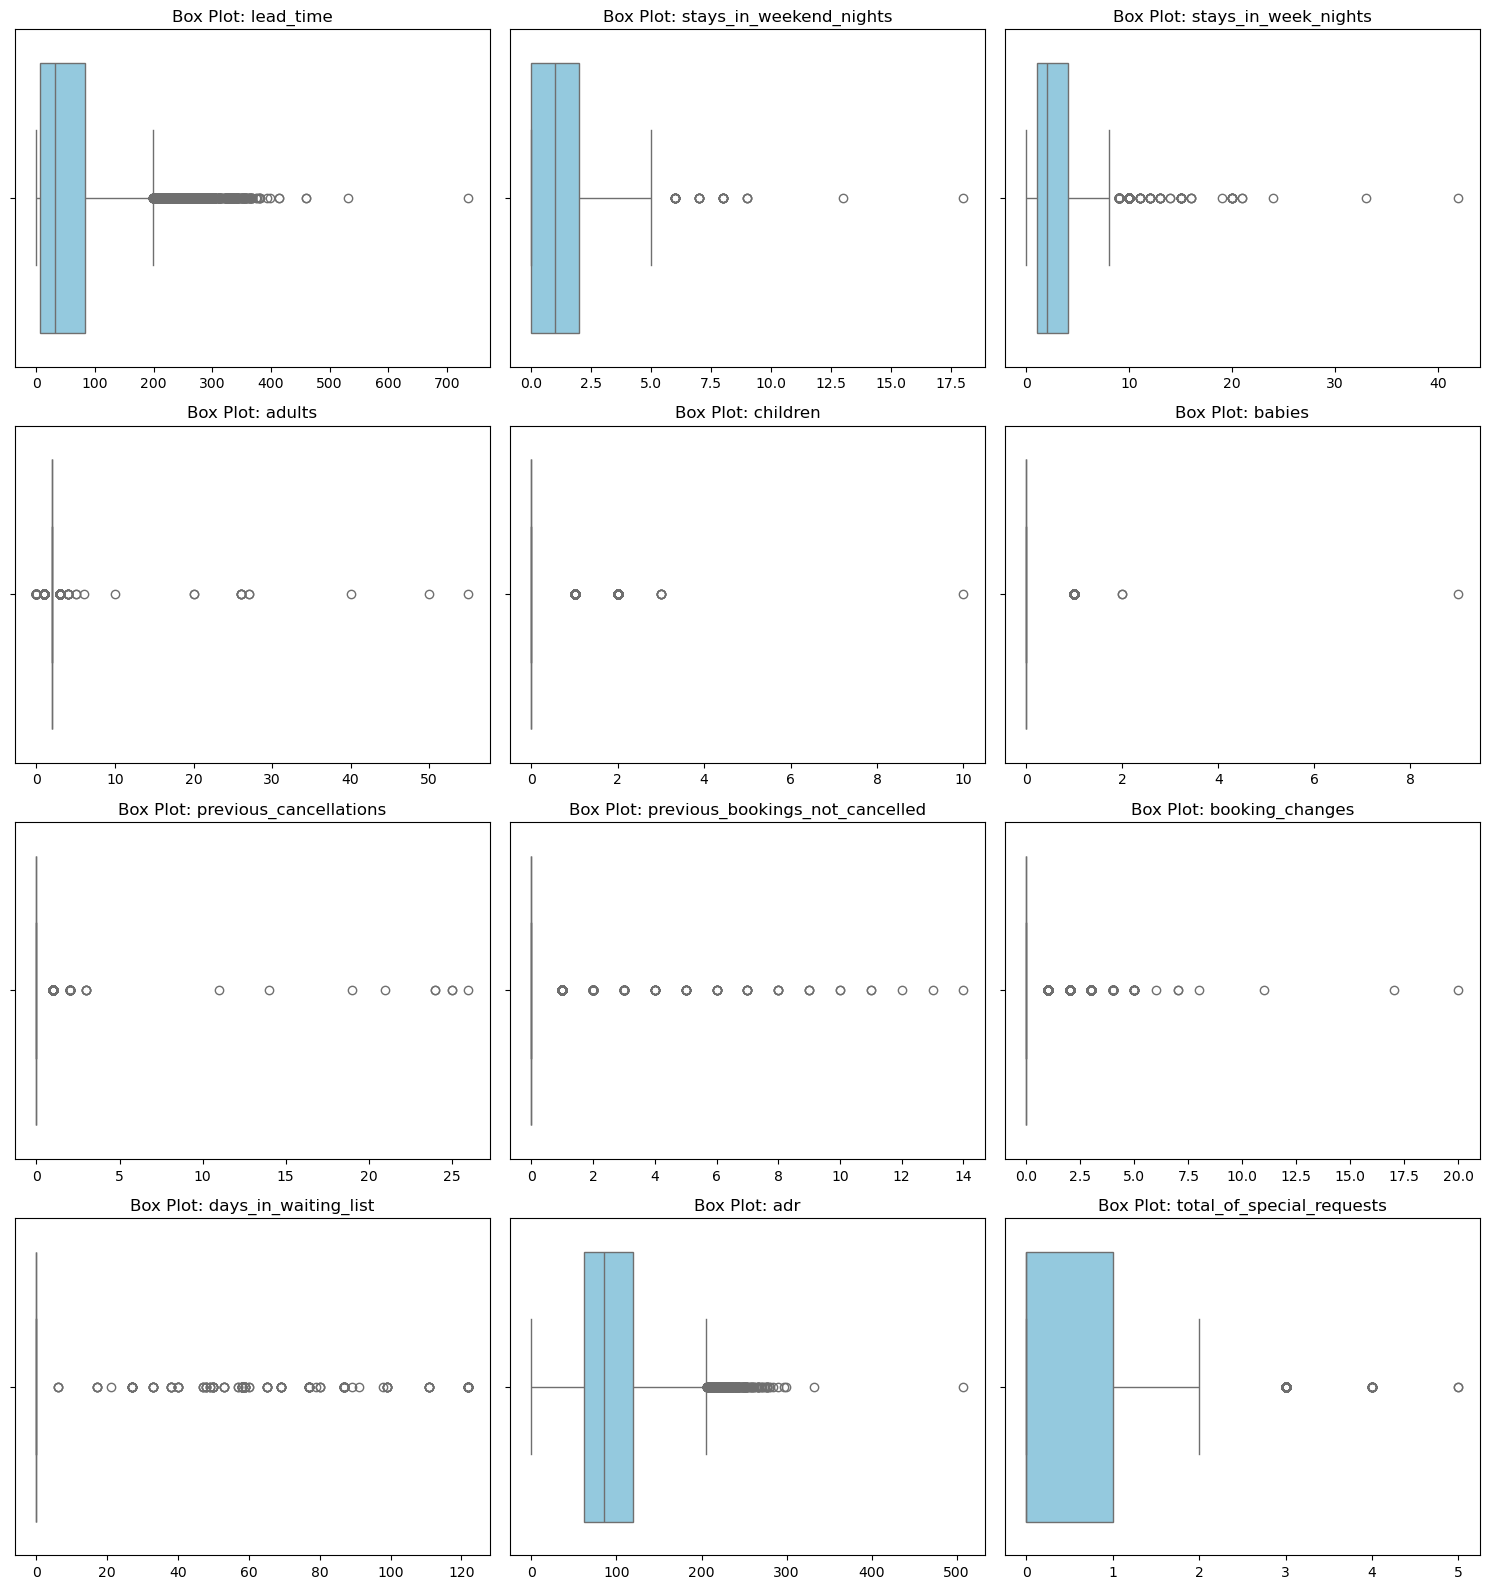

In [8]:
#whisker plot
cols_to_plot = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'total_of_special_requests',
]

#set up grid layout
num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols_to_plot, 1):
  plt.subplot(rows, cols_per_row, i)
  sns.boxplot(x=df[col], color='skyblue')
  plt.title(f'Box Plot: {col}', fontsize=12)
  plt.xlabel('')

plt.tight_layout()
plt.show()

In [9]:
#quartiles - outlier removal


cols = ['lead_time', 'adr']

#Calculate Q1, Q3, IQR
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

#define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#filter out outliers
clean_df = df[
    ~((df[cols] < lower_bound) | (df[cols] > upper_bound)).any(axis=1)
]

#print outlier counts
for col in cols:
  col_outliers = df[
      (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
  ]

print(f'Number of outliers in {col}: {len(col_outliers)}')
print(f'Original rows: {len(df)}')
print(f'Rows after cleaning: {len(clean_df)}')

Number of outliers in adr: 290
Original rows: 13313
Rows after cleaning: 12121


In [10]:
clean_df = clean_df[clean_df['stays_in_weekend_nights'] <=7]
clean_df = clean_df[clean_df['stays_in_week_nights'] <=20]
clean_df = clean_df[clean_df['adults'].between(1, 5)]
clean_df = clean_df[clean_df['children'] <=4]
clean_df = clean_df[clean_df['babies'] <=2]
clean_df = clean_df[clean_df['previous_cancellations'] <=15]

print(f"Final row count after all cleaning steps: {len(clean_df)}")

Final row count after all cleaning steps: 12064


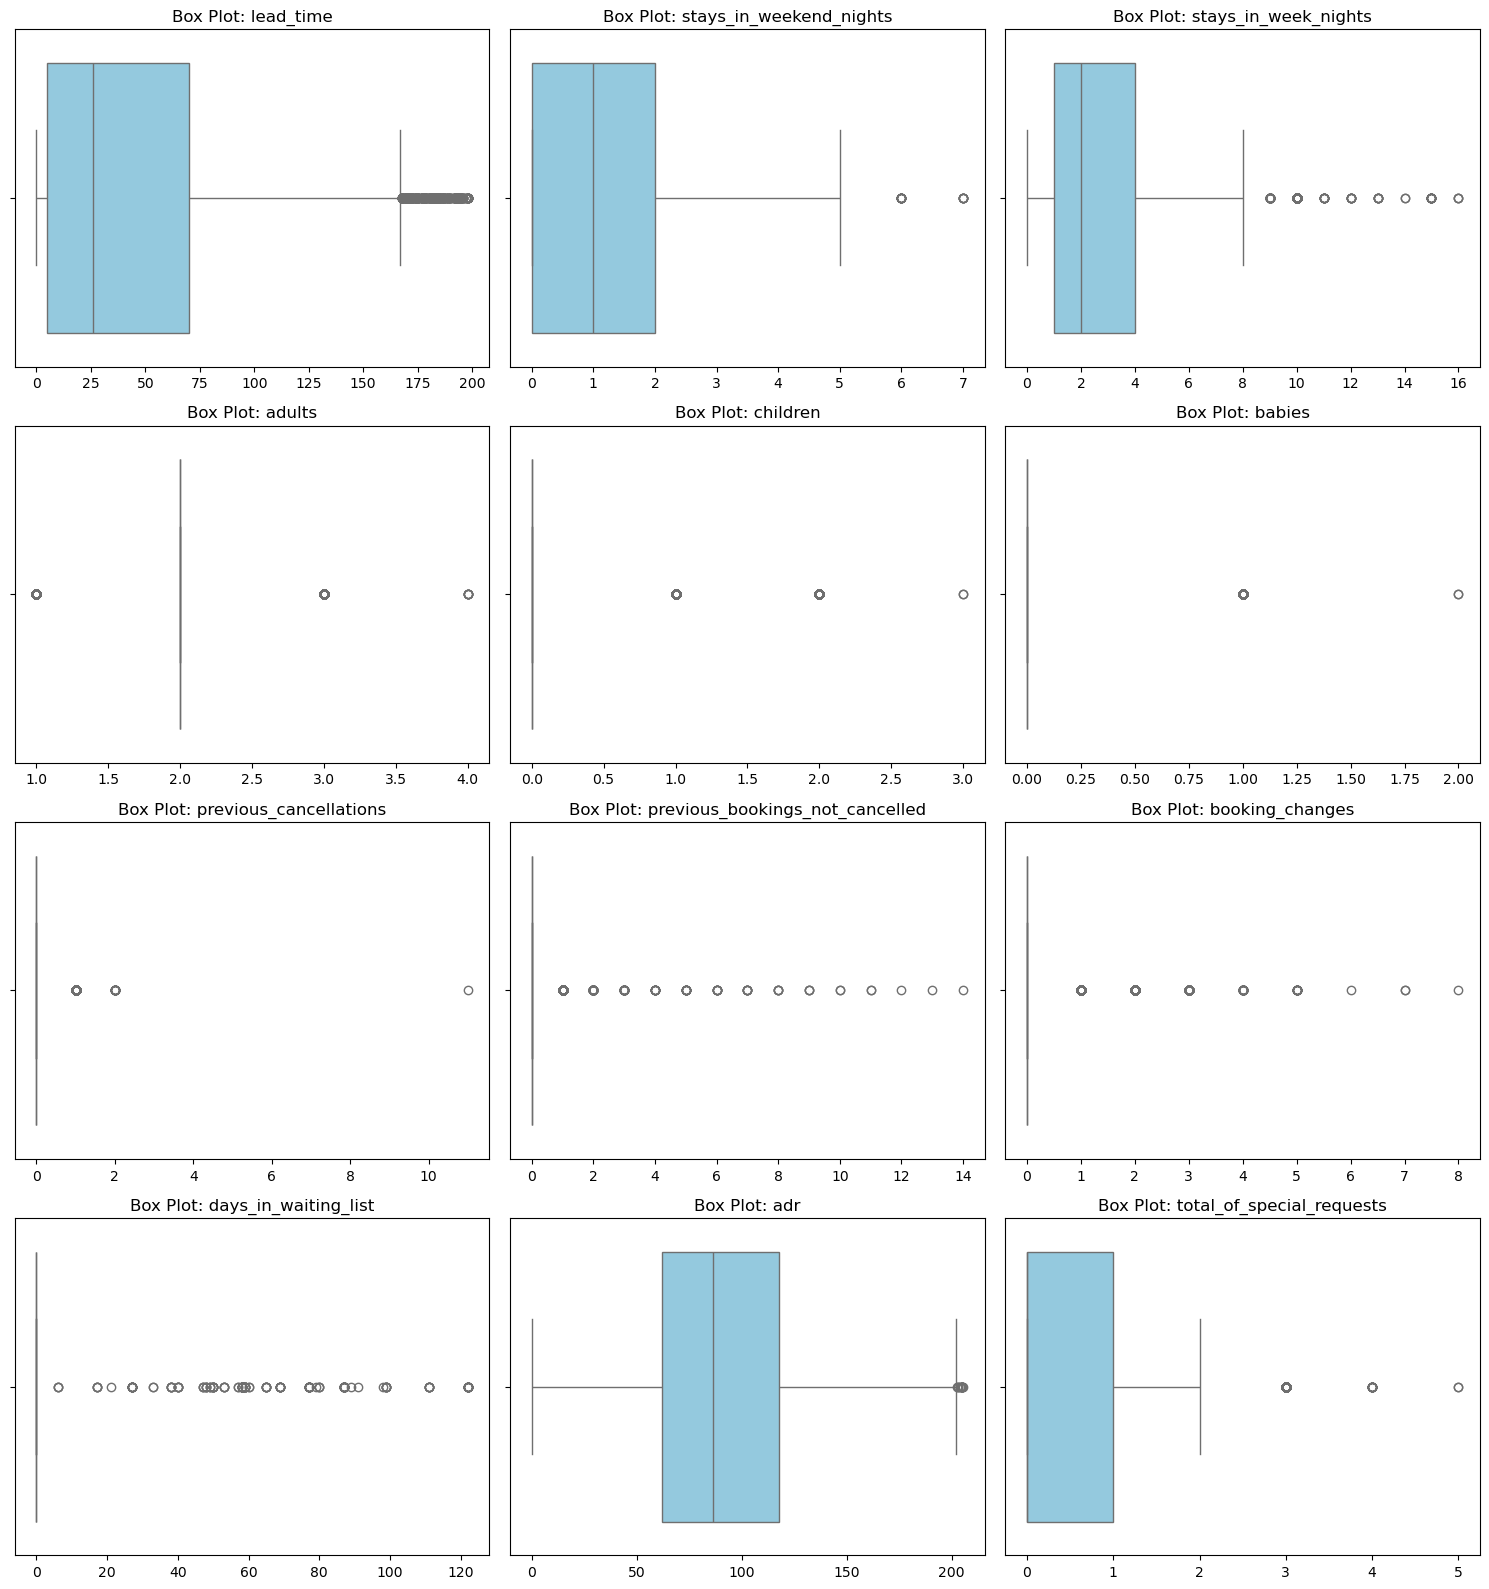

In [11]:
cols_to_plot = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'total_of_special_requests',
]

num_vars = len(cols_to_plot)
cols_per_row = 3
rows = (num_vars + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols_to_plot, 1):
  plt.subplot(rows, cols_per_row, i)
  sns.boxplot(x=clean_df[col], color='skyblue')
  plt.title(f'Box Plot: {col}', fontsize=12)
  plt.xlabel('')

plt.tight_layout()
plt.show()

<div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 03</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Irrelevant Data</span>
</div>

In [12]:
print(clean_df.columns)

Index(['hotel_type', 'is_cancelled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_cancelled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [13]:
#remove columns you don't need
#keep all date columns to convert first
clean_df = clean_df.drop(columns=['agent',
                                  'company',
                                 # 'reservation_status'
                                  'reservation_status_date'])

  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 04</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Standardize Capitalization</span>
</div>

In [14]:
#n/a

  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 05</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Convert Data Types</span>
</div>

In [15]:
#convert to datetime
date_strings=clean_df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' + 
    df['arrival_date_month'].astype(str) + '-' + 
    df['arrival_date_day_of_month'].astype(str)
)
clean_df['arrival_date'] = pd.to_datetime(date_strings, format='%Y-%B-%d')

#clean_df['reservation_status_date'] = pd.to_datetime
#clean_df['reservation_status_date'] = pd.to_datetime(date_strings, format='%Y-%B-%d')

In [16]:
#drop irrelevant columns
clean_df = clean_df.drop(columns=['arrival_date_year',
'arrival_date_month',
'arrival_date_week_number',
'arrival_date_day_of_month'])

In [17]:
# Convert to integer
int_cols = [
    'lead_time',
    'adults',
   # 'agent',
   # 'company',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]
clean_df[int_cols] = clean_df[int_cols].astype(int)

# Convert to float
clean_df['adr'] = clean_df['adr'].astype(float)

# Convert to string/object
str_cols = [
    'hotel_type',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]
clean_df[str_cols] = clean_df[str_cols].astype(str)

# Convert to boolean
clean_df['is_cancelled'] = clean_df['is_cancelled'].astype(bool)
clean_df['is_repeated_guest'] = clean_df['is_repeated_guest'].astype(bool)

In [18]:
clean_df.head(5)

,hotel_type,is_cancelled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,arrival_date
0,Resort Hotel,True,85,0,3,2,0,0,Bed & Breakfast,PRT,...,A,0,No Deposit,0,Transient,82.0,0,1,Canceled,2018-07-01
1,Resort Hotel,True,75,0,3,2,0,0,Half Board,PRT,...,D,0,No Deposit,0,Transient,105.5,0,0,Canceled,2018-07-01
2,Resort Hotel,True,23,0,4,2,0,0,Bed & Breakfast,PRT,...,E,0,No Deposit,0,Transient,123.0,0,0,Canceled,2018-07-01
3,Resort Hotel,True,60,2,5,2,0,0,Bed & Breakfast,PRT,...,E,0,No Deposit,0,Transient,107.0,0,2,Canceled,2018-07-01
4,Resort Hotel,True,96,2,8,2,0,0,Bed & Breakfast,PRT,...,E,0,No Deposit,0,Transient,108.3,0,2,Canceled,2018-07-01


  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 06</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Remove Formatting</span>
</div>

In [19]:
#n/a

  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 07</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Fix Errors</span>
</div>

In [20]:
#already done - spelling of cancelled vs. canceled 

  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 08</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Language Translation</span>
</div>

In [22]:
#n/a

  <div style="margin: 20px 0 12px 0; border-bottom: 2px solid #2D6A4F
    ; padding-bottom: 6px;">
    <span style="background: linear-gradient(135deg, #2D6A4F
                                             0%, #2D6A4F
                                             100%); color: white; padding: 4px 10px; border-radius: 4px; font-size: 11px; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">STEP 09</span>
    <span style="font-size: 16px; font-weight: 700; color: #1e293b; margin-left: 8px;">Handle Missing Values</span>
</div>

In [23]:
#already done using:
##change n/a to 0
#df = df.fillna(0)

In [25]:
cols_to_check = ['country']

for col in cols_to_check:
    clean_df = clean_df[clean_df[col].astype(str) != '0']

In [26]:
#pickle
all_dfs = {
    "df" : df,
    "clean_df": clean_df,
}
pd.to_pickle(all_dfs, 'all_clean_dfs2.pkl')